In [58]:
import mesa
import seaborn as sns
import numpy as np
import pandas as pd

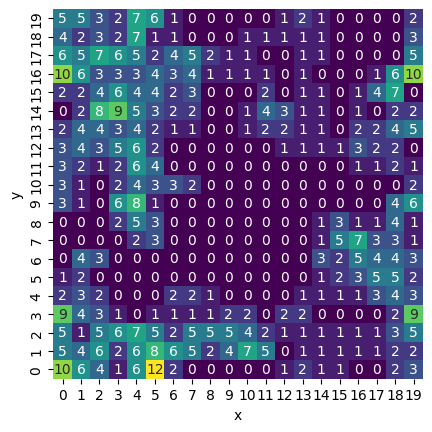

In [146]:
class UAVModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, num_agents, width, height):
        super().__init__()
        self.num_agents = num_agents
        self.grid = mesa.space.MultiGrid(width, height, True) # creates space
        self.coverage = np.zeros((height, width), dtype=int) # coverage matrix to track visits per cell
        agents = UAVAgent.create_agents(model=self, n=num_agents) # creates agents
        for a in agents:
            self.grid.place_agent(a, (0, 0)) # positions agents at a common starting point
            a.track_position()
            a.inspect()

    def step(self):
        self.agents.do("move")
        self.agents.do("inspect")


class UAVAgent(mesa.Agent):
    """A model with UAV agents exploring a 2D grid and recording coverage"""

    def __init__(self, model):
        super().__init__(model) 
        self.track = []

    def track_position(self):
        self.track.append(self.pos)

    def move(self):
        """Moves the drone to another cell"""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=False, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)
        self.track_position()

    def inspect(self):
        """Drone inspects the cell"""
        y, x = self.pos
        self.model.coverage[y][x] += 1


N_AGENTS = 5
GRID_SIZE = 20
ITERATIONS = 150

model = UAVModel(N_AGENTS,GRID_SIZE,GRID_SIZE)  # Tells the model to create 10 agents
for _ in range(ITERATIONS):  # Runs the model for 10 steps; an underscore is common convention for a variable that is not used
    model.step()


data = model.coverage

ax = sns.heatmap(data, cmap="viridis", annot=True, cbar=False, square=True)
ax.invert_yaxis()  # put y=0 at the bottom
ax.set_xlabel("x")
ax.set_ylabel("y");